In [14]:
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    pipeline,
    Trainer,
    TrainingArguments,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [15]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [16]:
dataset = load_dataset("dair-ai/emotion", trust_remote_code=True)

for split in dataset.keys():
    print(f"{split}: {len(dataset[split])} примеров")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров


In [17]:
classes = dataset['train'].features['label'].names
print(f"Метки классов: {classes}")
print("\nПримеры текстов:")
for i in range(5):
    text = dataset['train'][i]['text']
    label_id = dataset['train'][i]['label']
    print(f"'{text}' | Label: {label_id} ({classes[label_id]})")

Метки классов: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры текстов:
'i didnt feel humiliated' | Label: 0 (sadness)
'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake' | Label: 0 (sadness)
'im grabbing a minute to post i feel greedy wrong' | Label: 3 (anger)
'i am ever feeling nostalgic about the fireplace i will know that it is still on the property' | Label: 2 (love)
'i am feeling grouchy' | Label: 3 (anger)


В данном датасете классифицируется эмоциональная окраска текста. Всего 6 классов: грусть, удовольствие, любовь, злость, страх, удивление.

In [18]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

sample_texts = dataset['train']['text'][:3]

# Пример с padding и truncation
encoded_samples = tokenizer(
    sample_texts,
    padding='max_length',
    truncation=True,
    max_length=20,
    return_tensors='pt'
)

for i, text in enumerate(sample_texts):
    print(f"Оригинальный текст: {text}")

    # Токены
    tokens = tokenizer.convert_ids_to_tokens(encoded_samples['input_ids'][i])
    print(f"Токены: {tokens}")

    # input_ids
    print(f"input_ids: {encoded_samples['input_ids'][i].tolist()}")

    # attention_mask (1 - реальный токен, 0 - padding)
    print(f"attention_mask: {encoded_samples['attention_mask'][i].tolist()}")
    print("-" * 50)

print("\nSpecial tokens:", tokenizer.special_tokens_map)

Оригинальный текст: i didnt feel humiliated
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------------------------------------
Оригинальный текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
----------------------------------

In [34]:
zero_shot_classifier = pipeline("text-classification", model=model_checkpoint, device=0 if torch.cuda.is_available() else -1)

print("Инференс недообученной модели на 3 примерах:")
for text in sample_texts:
    pred = zero_shot_classifier(text)
    print(f"Текст: '{text}' -> Предсказание: {pred}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Инференс недообученной модели на 3 примерах:
Текст: 'i didnt feel humiliated' -> Предсказание: [{'label': 'LABEL_1', 'score': 0.5071464776992798}]
Текст: 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake' -> Предсказание: [{'label': 'LABEL_1', 'score': 0.5035860538482666}]
Текст: 'im grabbing a minute to post i feel greedy wrong' -> Предсказание: [{'label': 'LABEL_1', 'score': 0.5000088810920715}]


Мы взяли базовую модель без дообучения, и такой вариант под нашу задачу не подходит: для всех 3 примеров модель предсказала лейбл joy, хотя на самом деле у первых двух текстов лейбл sadness, а у третьего - anger.

In [20]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

id2label = {i: label for i, label in enumerate(classes)}
label2id = {label: i for i, label in enumerate(classes)}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(classes),
    id2label=id2label,
    label2id=label2id
).to(device)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": acc, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [22]:
trainer.train()

print("\nОценка на test:")
test_results = trainer.evaluate(tokenized_datasets["test"])
print(test_results)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.255033,0.206502,0.923000,0.896508
2,0.155496,0.161388,0.936500,0.907538
3,0.110853,0.168390,0.935500,0.909325
4,0.082605,0.191365,0.939500,0.916910
5,0.061390,0.195865,0.936000,0.910937


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Оценка на test:


{'eval_loss': 0.21278756856918335, 'eval_accuracy': 0.928, 'eval_f1_macro': 0.8812936226278021, 'eval_runtime': 4.2018, 'eval_samples_per_second': 475.992, 'eval_steps_per_second': 29.749, 'epoch': 5.0}


In [23]:
predictions_output = trainer.predict(tokenized_datasets["test"])
logits = predictions_output.predictions
true_labels = predictions_output.label_ids

probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
pred_labels = np.argmax(probs, axis=-1)
confidences = np.max(probs, axis=-1)

acc = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average='macro')
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Macro: {f1:.4f}")

Test Accuracy: 0.9280
Test F1 Macro: 0.8813


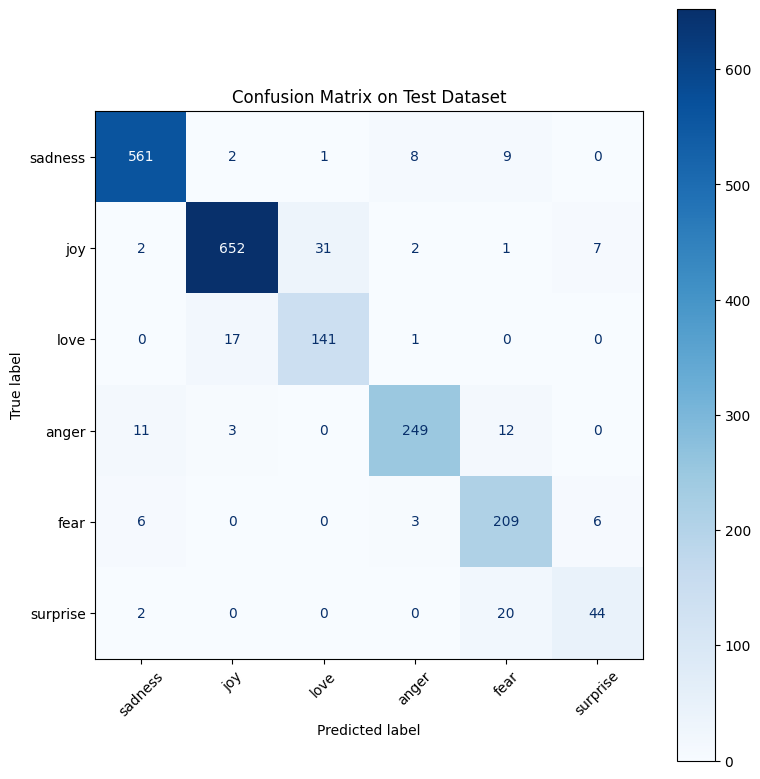

In [ ]:
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix on Test Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

In [ ]:
test_texts = dataset["test"]["text"]

df_preds = pd.DataFrame({
    "text": test_texts,
    "true_label": [classes[label] for label in true_labels],
    "pred_label": [classes[label] for label in pred_labels],
    "confidence": confidences
})

df_preds.to_csv("artifacts/sample_predictions.csv", index=False)
df_preds

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9996
1,im updating my blog because i feel shitty,sadness,sadness,0.9996
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9996
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9997
4,i was feeling a little vain when i did this one,sadness,sadness,0.9996
...,...,...,...,...
1995,i just keep feeling like someone is being unkind to me and doing me wrong and then all i can think of doing is to get back at them and t...,anger,anger,0.9993
1996,im feeling a little cranky negative after this doctors appointment,anger,anger,0.9994
1997,i feel that i am useful to my people and that gives me a great feeling of achievement,joy,joy,0.9996
1998,im feeling more comfortable with derby i feel as though i can start to step out my shell,joy,joy,0.9992


In [27]:
print("\n5 примеров предсказаний:")
display(df_preds.sample(5, random_state=42))


5 примеров предсказаний:


,text,true_label,pred_label,confidence
1860,i feel so dirty but after spending a day at the mk show me and a buddy decided we would get the two player starter between us luckily fo...,sadness,sadness,0.9995
353,i could feel his breath on me and smell the sweet scent of him,joy,love,0.9837
1333,i just want to feel loved by you,love,love,0.9981
905,i have felt the need to write out my sometimes anxious feelings impatient thoughts lists of things that still should could be done befor...,anger,anger,0.5888
1289,at a party i met a girl who drew me to her,anger,anger,0.8710


In [28]:
errors = df_preds[df_preds['true_label'] != df_preds['pred_label']]
print("\nПримеры ошибок модели:")
display(errors.head(5))


Примеры ошибок модели:


,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.5336
40,i feel if i completely hated things i d exercise my democratic right speak my mind in what ever ways possible and try to enact a change,anger,sadness,0.9062
67,i feel a bit stressed even though all the things i have going on are fun,anger,sadness,0.8364
72,i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird,surprise,fear,0.7559
86,i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love,joy,love,0.9217


Судя по ошибочным примерам, истинный и предсказанный лейбл это чаще всего похожие эмоции.